In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [ ]:
df = pd.read_csv('/content/data.csv', encoding = 'Latin-1')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
df.isnull()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.dropna(subset = ['CustomerID'], inplace = True)

In [ ]:
df['TotalPrice'] = df['Quantity']*df['UnitPrice']

In [14]:

customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceNo': 'NumPurchases',
    'Quantity': 'TotalQuantity',
    'TotalPrice': 'TotalSpent'
}).reset_index()

In [16]:
X = customer_df[['NumPurchases', 'TotalQuantity']]
y = customer_df['TotalSpent']

In [17]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size =0.2, random_state = 42)

In [22]:
model = DecisionTreeRegressor(max_depth= 5, random_state=42)
model.fit(X_train , y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [29]:
y_pred =  model.predict(X_test)

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 713.90
MSE: 12335566.98
RMSE: 3512.20
R² Score: 0.82


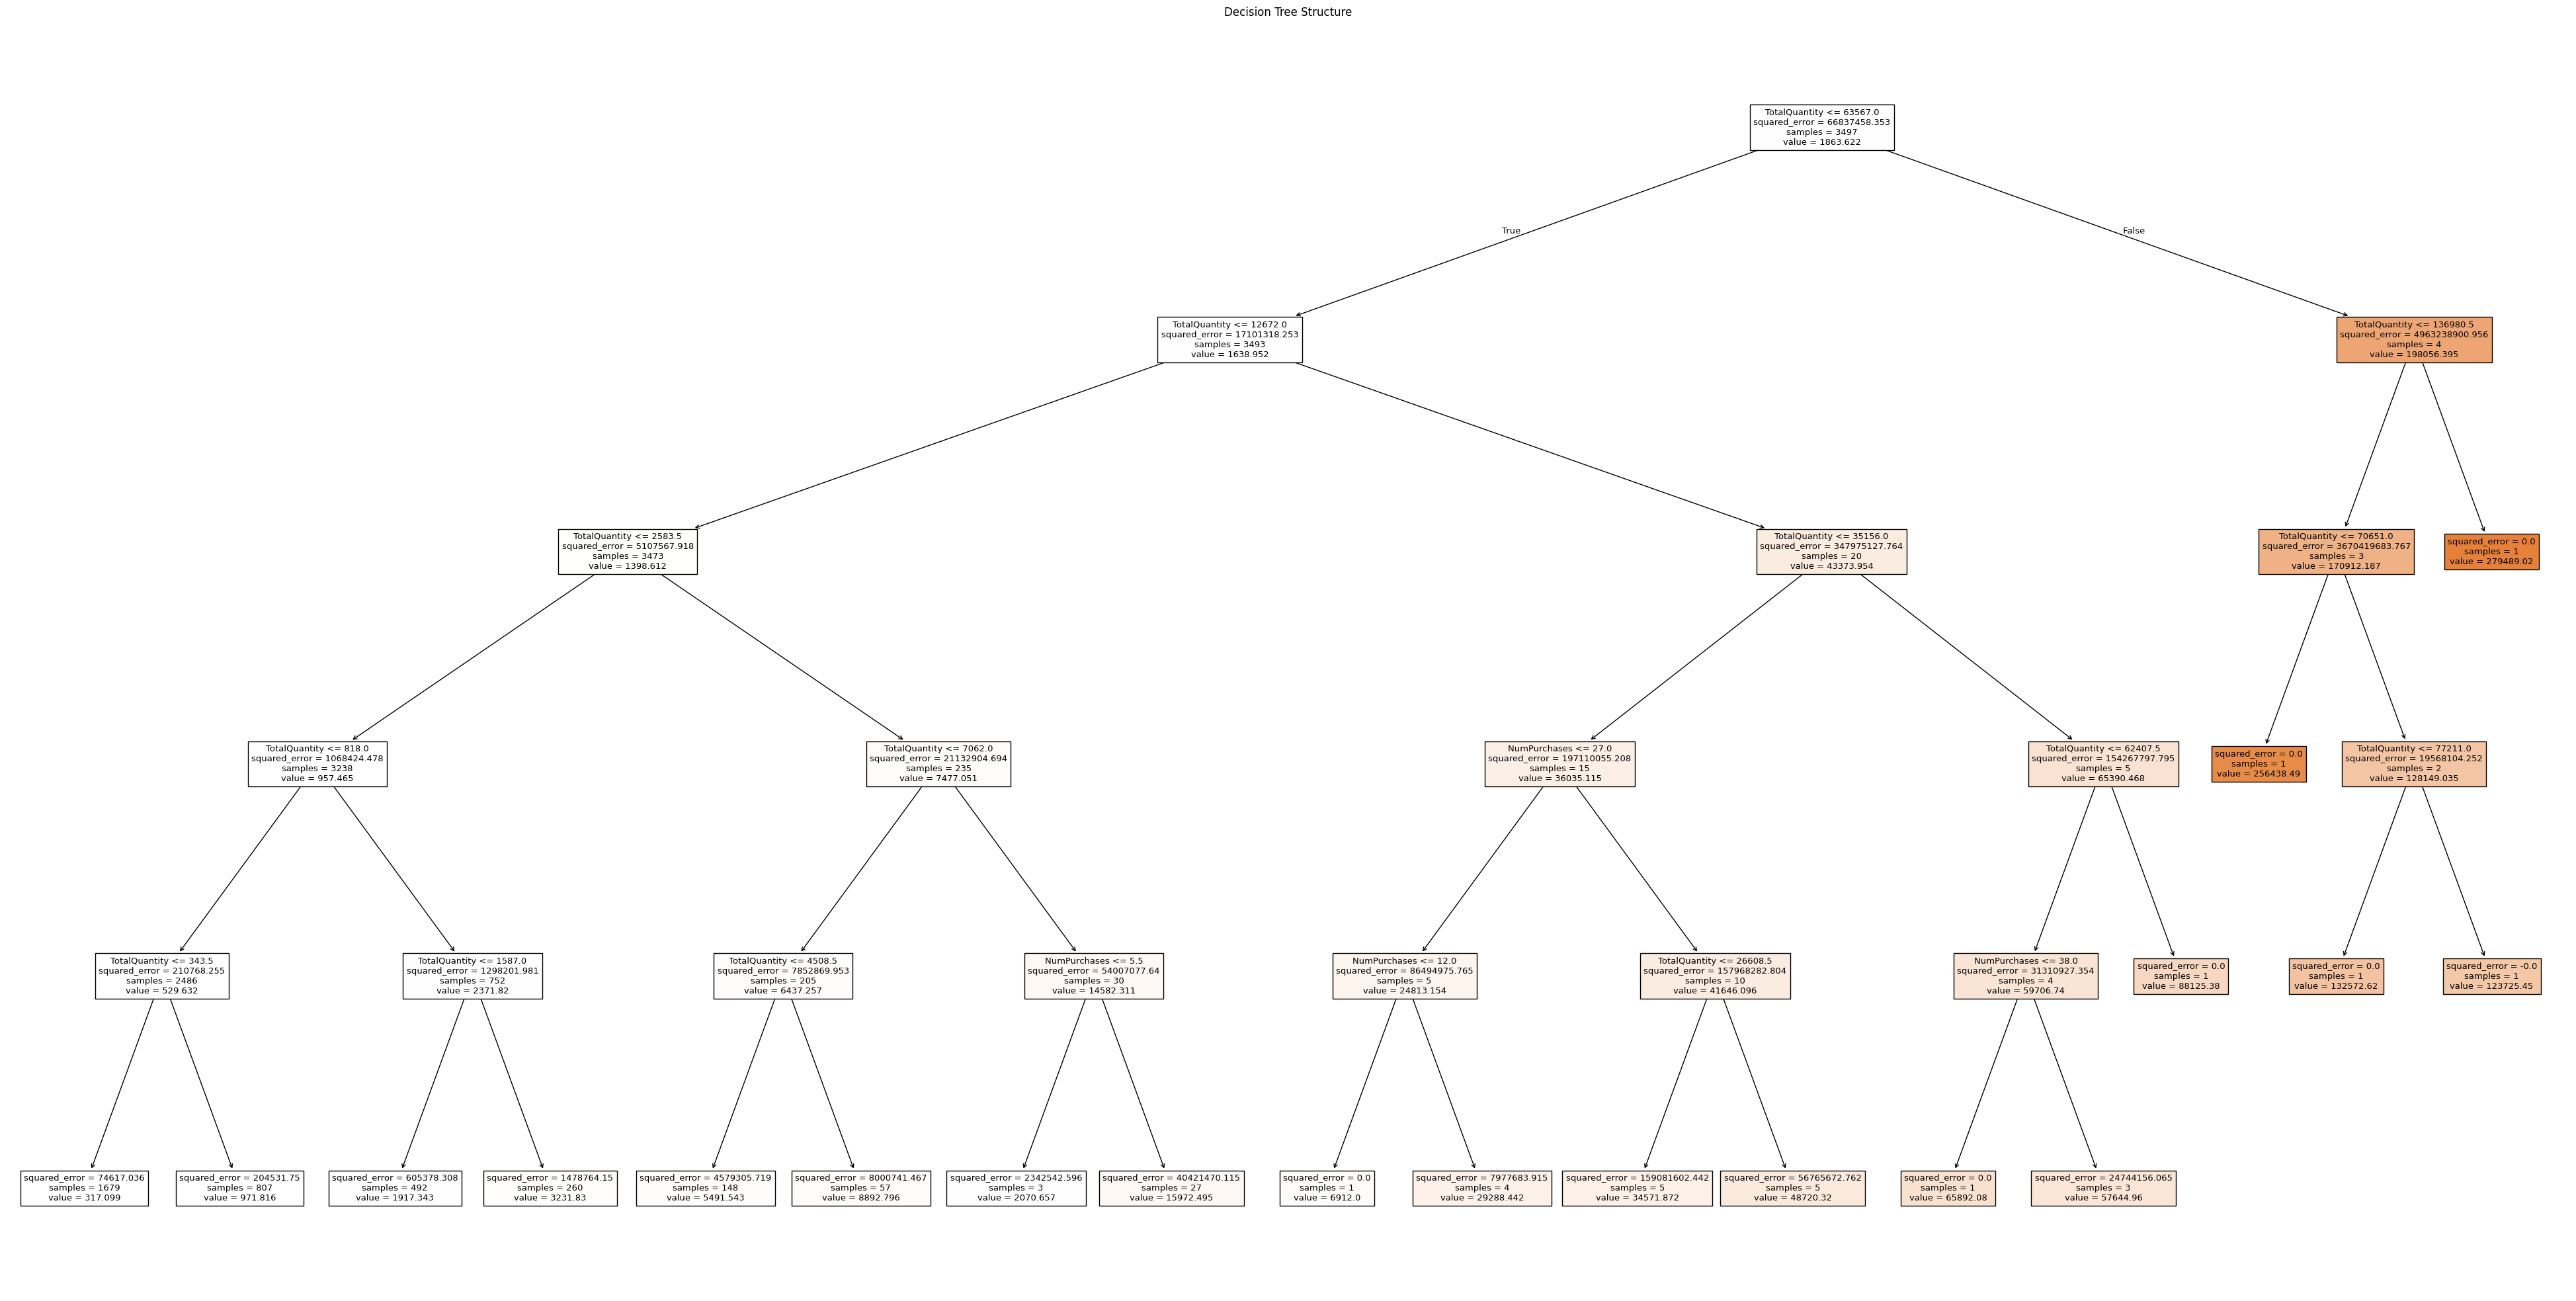

In [36]:
from sklearn import tree
plt.figure(figsize=(50,25))
tree.plot_tree(model, feature_names = X.columns, filled = True)
plt.title("Decision Tree Structure")
plt.show()


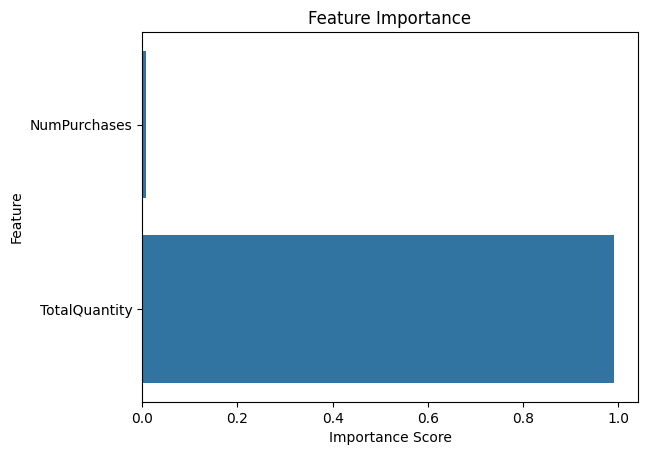

In [35]:
importances = model.feature_importances_
feature_names = X.columns

sns.barplot(x = importances, y = feature_names)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()